In [3]:
import os
print(os.getcwd())

c:\Users\Saisri\Desktop\sentiment_trading_analysis\notebooks


In [4]:
import os
print(os.getcwd())

c:\Users\Saisri\Desktop\sentiment_trading_analysis\notebooks


In [5]:
import pandas as pd

sentiment = pd.read_csv("../data/sentiment.csv")
trades = pd.read_csv("../data/trades.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [6]:
import os
print(os.listdir("../data"))

['sentiment.csv', 'trades.csv']


In [7]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Info:")
sentiment.info()

print("\nTrades Info:")
trades.info()

print("\nMissing Values:")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Info:
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB

Trades Info:
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 n

In [11]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [12]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='str')


In [15]:
# Remove duplicates
trades.drop_duplicates(inplace=True)

# Drop rows where important values are missing
trades = trades.dropna(subset=['closed_pnl'])

In [17]:
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    format='%d-%m-%Y %H:%M'
)

In [18]:
print(trades['timestamp_ist'].isnull().sum())

0


In [19]:
trades = trades.dropna(subset=['timestamp_ist'])

In [20]:
# Create date column
trades['date'] = trades['timestamp_ist'].dt.date

In [27]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [28]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [29]:
trades['date'] = trades['timestamp_ist'].dt.date

In [30]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(merged.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [31]:
print("Missing sentiment:", merged['classification'].isnull().sum())

Missing sentiment: 6


In [32]:
merged = merged.dropna(subset=['classification'])

In [33]:
print("After cleaning:", merged.shape)

After cleaning: (211218, 18)


In [34]:
pnl_sentiment = merged.groupby('classification')['closed_pnl'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64


In [36]:
merged['win'] = merged['closed_pnl'] > 0

In [37]:
print(merged[['closed_pnl','win']].head())

   closed_pnl    win
0         0.0  False
1         0.0  False
2         0.0  False
3         0.0  False
4         0.0  False


In [38]:
merged = merged[merged['closed_pnl'] != 0]

In [39]:
print(merged[['closed_pnl','win']].head())

     closed_pnl   win
44  3008.231185  True
45    30.741534  True
46    40.770089  True
47   243.812267  True
48   254.263735  True


In [40]:
merged['win'] = merged['closed_pnl'] > 0

In [41]:
pnl_sentiment = merged.groupby('classification')['closed_pnl'].mean()
print(pnl_sentiment)

win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear      71.027316
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Name: closed_pnl, dtype: float64
classification
Extreme Fear     0.762156
Extreme Greed    0.891670
Fear             0.872886
Greed            0.768907
Neutral          0.823889
Name: win, dtype: float64


In [42]:
threshold = merged['size_usd'].median()

merged['size_group'] = merged['size_usd'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

seg_size = merged.groupby(['size_group','classification'])['closed_pnl'].mean()
print(seg_size)

size_group  classification
High        Extreme Fear      119.181067
            Extreme Greed     287.144139
            Fear              196.261288
            Greed             172.527000
            Neutral           141.211080
Low         Extreme Fear        2.431781
            Extreme Greed      17.568734
            Fear                7.583392
            Greed               7.024059
            Neutral             4.552870
Name: closed_pnl, dtype: float64


In [43]:
trade_counts = merged.groupby('account').size()

threshold = trade_counts.median()

merged['trader_type'] = merged['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Rare'
)

seg_trader = merged.groupby(['trader_type','classification'])['closed_pnl'].mean()
print(seg_trader)

trader_type  classification
Frequent     Extreme Fear       42.766671
             Extreme Greed     120.172656
             Fear               68.384101
             Greed              43.499236
             Neutral            66.597243
Rare         Extreme Fear      212.460998
             Extreme Greed     276.884945
             Fear              404.203341
             Greed             485.473478
             Neutral           129.017961
Name: closed_pnl, dtype: float64


In [44]:
pnl_std = merged.groupby('account')['closed_pnl'].std()

threshold = pnl_std.median()

merged['consistency'] = merged['account'].apply(
    lambda x: 'Consistent' if pnl_std[x] < threshold else 'Inconsistent'
)

seg_consistency = merged.groupby(['consistency','classification'])['closed_pnl'].mean()
print(seg_consistency)

consistency   classification
Consistent    Extreme Fear      -10.757240
              Extreme Greed      70.158242
              Fear               15.862886
              Greed              38.628868
              Neutral             9.037983
Inconsistent  Extreme Fear      163.781334
              Extreme Greed     564.107547
              Fear              206.573977
              Greed             182.943684
              Neutral           164.391678
Name: closed_pnl, dtype: float64


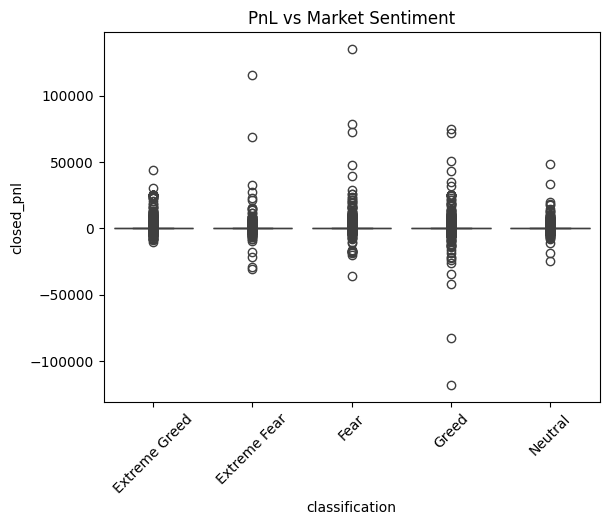

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.xticks(rotation=45)
plt.title("PnL vs Market Sentiment")
plt.show()

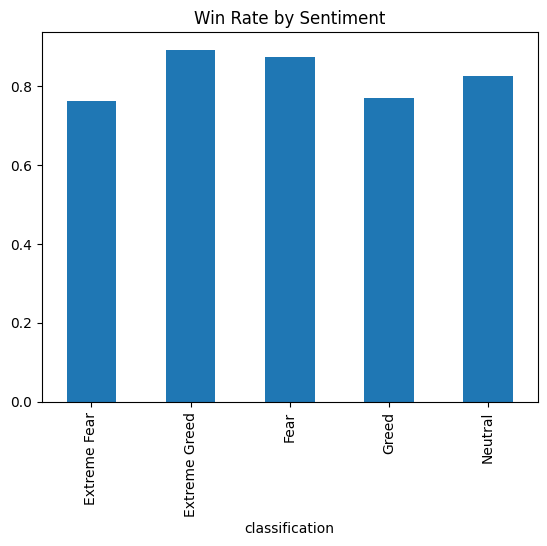

In [46]:
win_rate.plot(kind='bar', title='Win Rate by Sentiment')
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = merged[['size_usd']]
y = merged['win']

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7827286310869316


In [48]:
trade_freq = merged.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear     10406
Extreme Greed    20853
Fear             29808
Greed            25176
Neutral          18159
dtype: int64


In [49]:
size_behavior = merged.groupby('classification')['size_usd'].mean()
print(size_behavior)

classification
Extreme Fear     5467.570419
Extreme Greed    2779.563632
Fear             8041.140445
Greed            5438.671764
Neutral          5556.444833
Name: size_usd, dtype: float64


In [50]:
bias = merged.groupby(['classification','side']).size().unstack()
print(bias)

side              BUY   SELL
classification              
Extreme Fear     3123   7283
Extreme Greed    6500  14353
Fear             9230  20578
Greed           11343  13833
Neutral          5861  12298


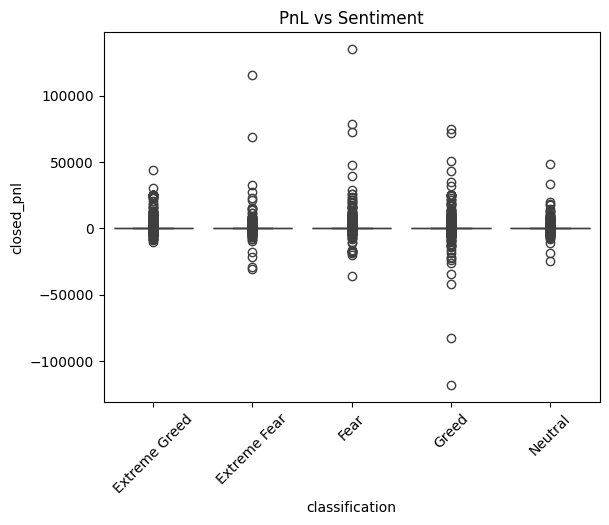

In [51]:
sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.xticks(rotation=45)
plt.title("PnL vs Sentiment")
plt.show()

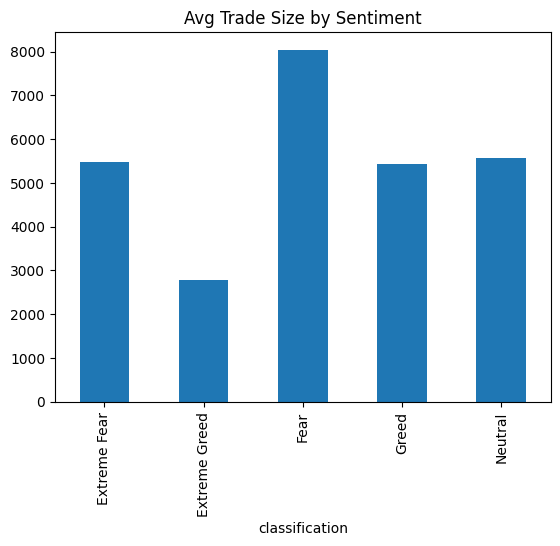

In [52]:
size_behavior.plot(kind='bar', title='Avg Trade Size by Sentiment')
plt.show()

In [58]:
import os

os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

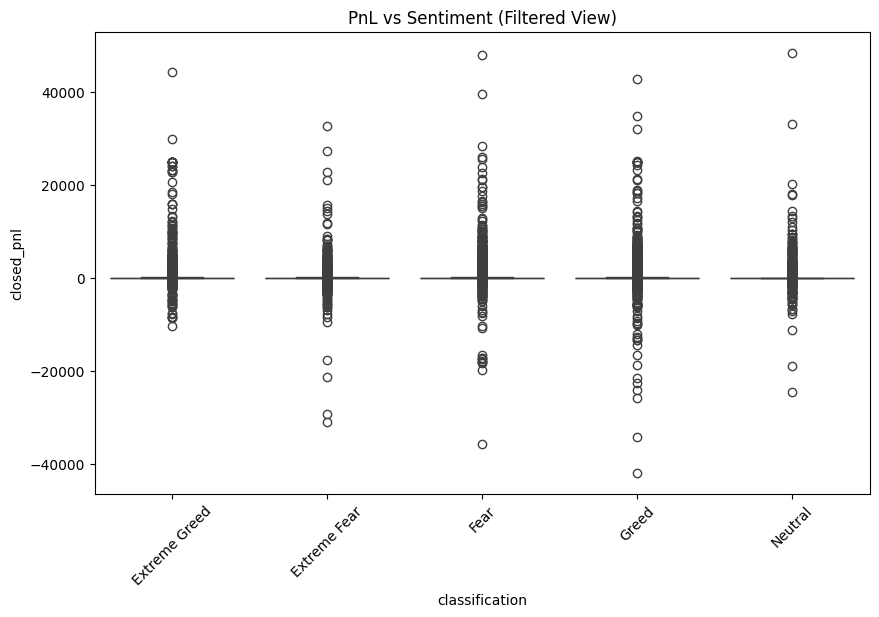

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/charts", exist_ok=True)

# Limit extreme values for better visualization
filtered = merged[(merged['closed_pnl'] > -50000) & (merged['closed_pnl'] < 50000)]

fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(x='classification', y='closed_pnl', data=filtered, ax=ax)

ax.set_title("PnL vs Sentiment (Filtered View)")
plt.xticks(rotation=45)

fig.savefig("outputs/charts/pnl_vs_sentiment_clean.png")
plt.show()
plt.close(fig)

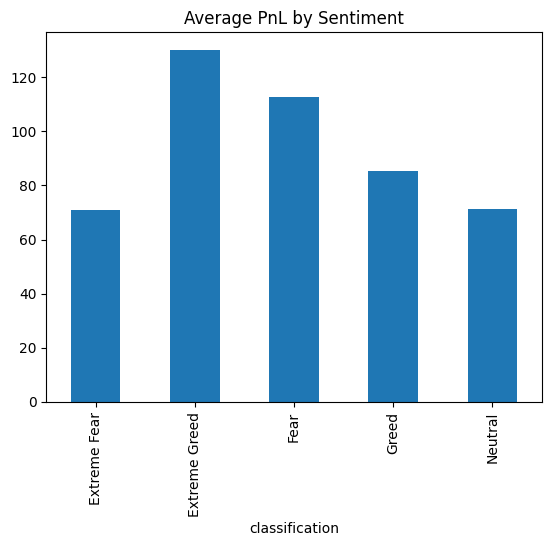

In [63]:
pnl_sentiment.plot(kind='bar', title='Average PnL by Sentiment')
plt.savefig("outputs/charts/pnl_bar.png")
plt.show()

In [69]:
# Convert to DataFrame
pnl_df = pnl_sentiment.reset_index()

# Rename columns
pnl_df.columns = ['classification', 'avg_pnl']

# Save INSIDE notebooks/outputs/tables
pnl_df.to_csv("outputs/tables/pnl_summary.csv", index=False)

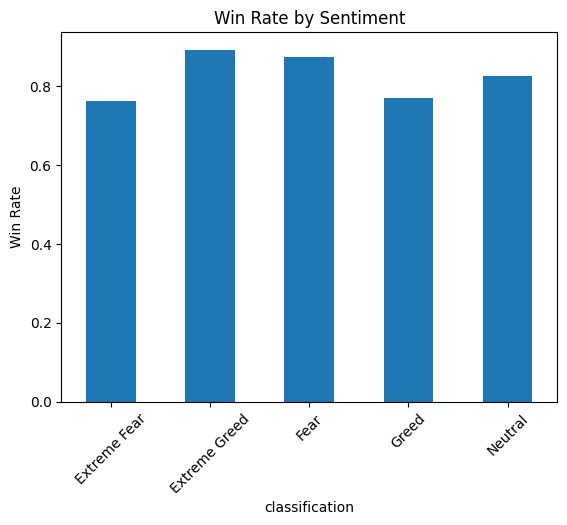

In [70]:
import matplotlib.pyplot as plt
import os

# Ensure folder exists
os.makedirs("outputs/charts", exist_ok=True)

# Plot
fig, ax = plt.subplots()
win_rate.plot(kind='bar', ax=ax)

ax.set_title("Win Rate by Sentiment")
ax.set_ylabel("Win Rate")
plt.xticks(rotation=45)

# Save
fig.savefig("outputs/charts/winrate.png")

plt.show()
plt.close(fig)

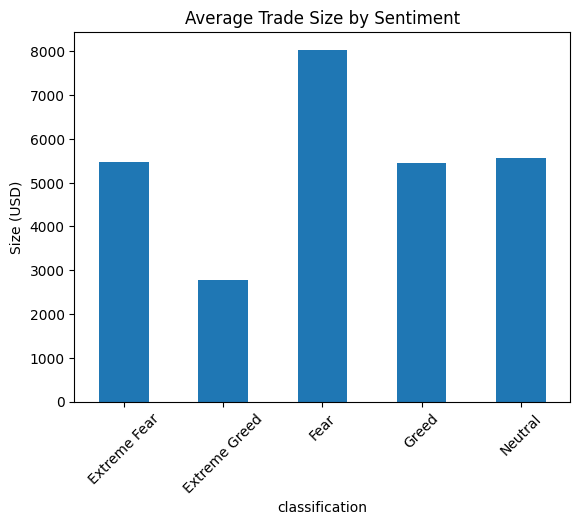

In [71]:
fig, ax = plt.subplots()

size_behavior.plot(kind='bar', ax=ax)

ax.set_title("Average Trade Size by Sentiment")
ax.set_ylabel("Size (USD)")
plt.xticks(rotation=45)

fig.savefig("outputs/charts/size_behavior.png")

plt.show()
plt.close(fig)